# Week 6 – Interactive Sales Dashboard  
## Data Visualization Mastery with Seaborn + Plotly

**Project Title:** Interactive Sales Dashboard  
**Tools Used:** Python,Pandas,Seaborn,Matplotlib,Plotly  
**Dataset:** sales_data.csv


## 1. Project Overview

This project is part of Week 6 of the internship program.  
The goal is to build a professional sales dashboard using multiple types of visualizations.

### Objectives
- Perform data cleaning and preparation
- Generate at least 5 different chart types
- Use Seaborn for statistical plots
- Add interactive charts using Plotly
- Create a dashboard-style layout and write meaningful insights


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")


## 2. Load Dataset

In this step, we load the dataset using Pandas and preview the first few rows to understand the structure.

In [3]:
df = pd.read_csv("sales_data.csv")
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


(100, 7)

## 3. Data Cleaning & Preparation

We clean the dataset to ensure accurate results.  
This includes fixing date formats,removing duplicates, and handling missing values.

In [5]:
df["Date"] = pd.to_datetime(df["Date"],errors="coerce")
df = df.dropna(subset=["Date"])
df = df.drop_duplicates()

# Convert numeric columns 
for col in ["Quantity","Price","Total_Sales"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Clean text columns
for col in ["Product","Region","Customer_ID"]:
    df[col] = df[col].astype(str).str.strip().str.title()

df.isnull().sum()


Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

## 4. Feature Engineering

We extract Month details from the Date column to support monthly trend analysis.

In [6]:
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

df[["Date","Month","Month_Name"]].head()

,Date,Month,Month_Name
0,2024-01-01,1,January
1,2024-01-02,1,January
2,2024-01-03,1,January
3,2024-01-04,1,January
4,2024-01-05,1,January


## 5. KPI Summary

We calculate basic KPIs to understand overall sales performance.

In [7]:
total_revenue = df["Total_Sales"].sum()
avg_order_value = df["Total_Sales"].mean()
top_product = df.groupby("Product")["Total_Sales"].sum().idxmax()

print("KPI SUMMARY")
print(f"Total Revenue      : ₹{total_revenue:,.0f}")
print(f"Average Order Value: ₹{avg_order_value:,.0f}")
print(f"Top Product        : {top_product}")


KPI SUMMARY
Total Revenue      : ₹12,365,048
Average Order Value: ₹123,650
Top Product        : Laptop


## 6. Visualization 1 : Sales Trend (Line Chart)

**What we see:** Sales over time  
**What it means:** Helps identify increasing/decreasing trends  
**Action:** Use this for planning inventory and promotions


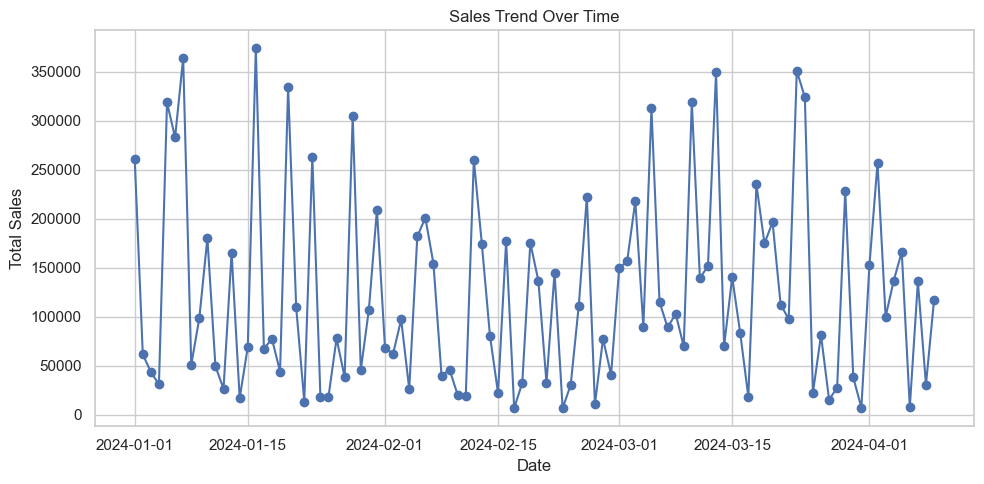

In [8]:
daily_sales = df.groupby("Date")["Total_Sales"].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(daily_sales["Date"],daily_sales["Total_Sales"],marker="o")
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


## 7. Visualization 2 : Sales by Product (Bar Chart)

**What we see:** Total sales by product category  
**What it means:** Identifies best-performing products  
**Action:** Increase focus on high-performing products


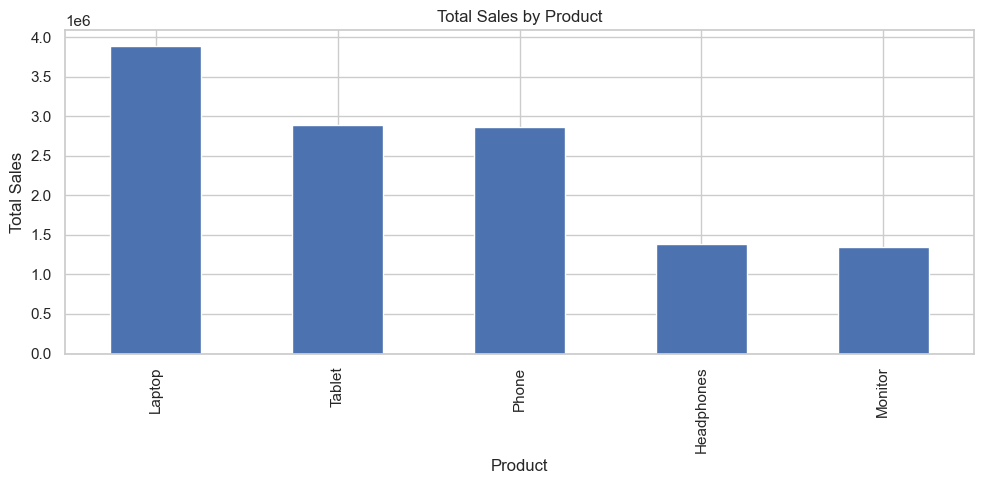

In [9]:
product_sales = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
product_sales.plot(kind="bar")
plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

## 8. Visualization 3 : Sales Distribution by Region (Box Plot)

**What we see:** Distribution and outliers of sales per region  
**What it means:** Shows which regions have higher variability or strong sales  
**Action:** Target marketing based on regional sales behavior

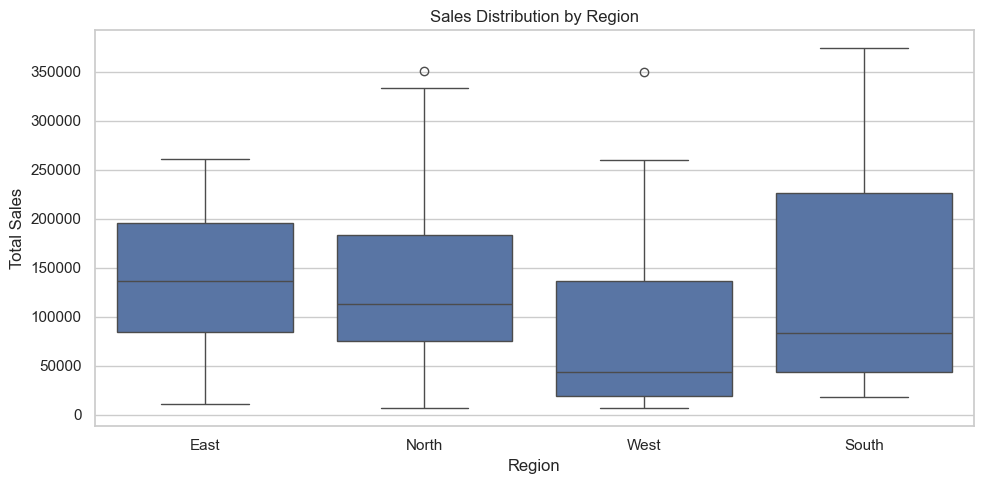

In [10]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x="Region",y="Total_Sales")
plt.title("Sales Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

## 9. Visualization 4 : Sales Distribution by Product (Violin Plot)

**What we see:** Sales density and spread by product  
**What it means:** Helps identify products with consistent vs variable sales  
**Action:** Focus on products with strong and stable performance


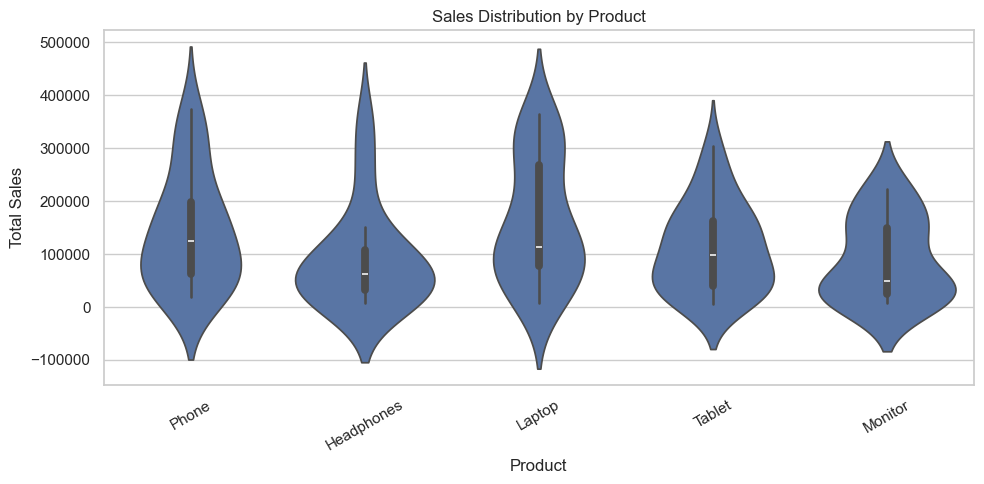

In [11]:
plt.figure(figsize=(10,5))
sns.violinplot(data=df,x="Product",y="Total_Sales")
plt.title("Sales Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 10. Visualization 5 : Correlation Heatmap

**What we see:** Relationship between Quantity,Price and Total Sales  
**What it means:** Shows which features influence sales more  
**Action:** Useful for strategy and forecasting


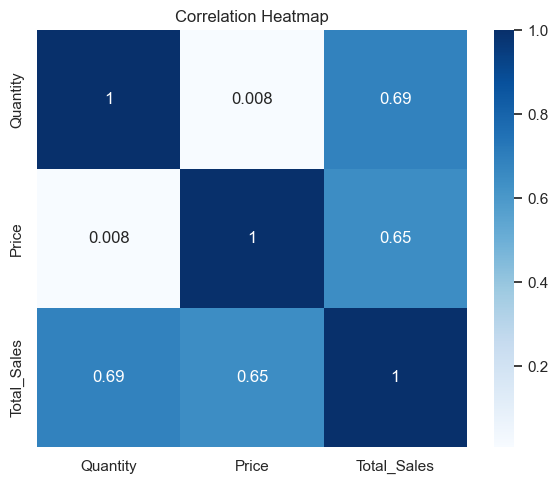

In [12]:
corr = df[["Quantity","Price","Total_Sales"]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr,annot=True,cmap="Blues")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 11. Dashboard Layout (2×2 grid)

This section combines multiple charts into one dashboard style layout.


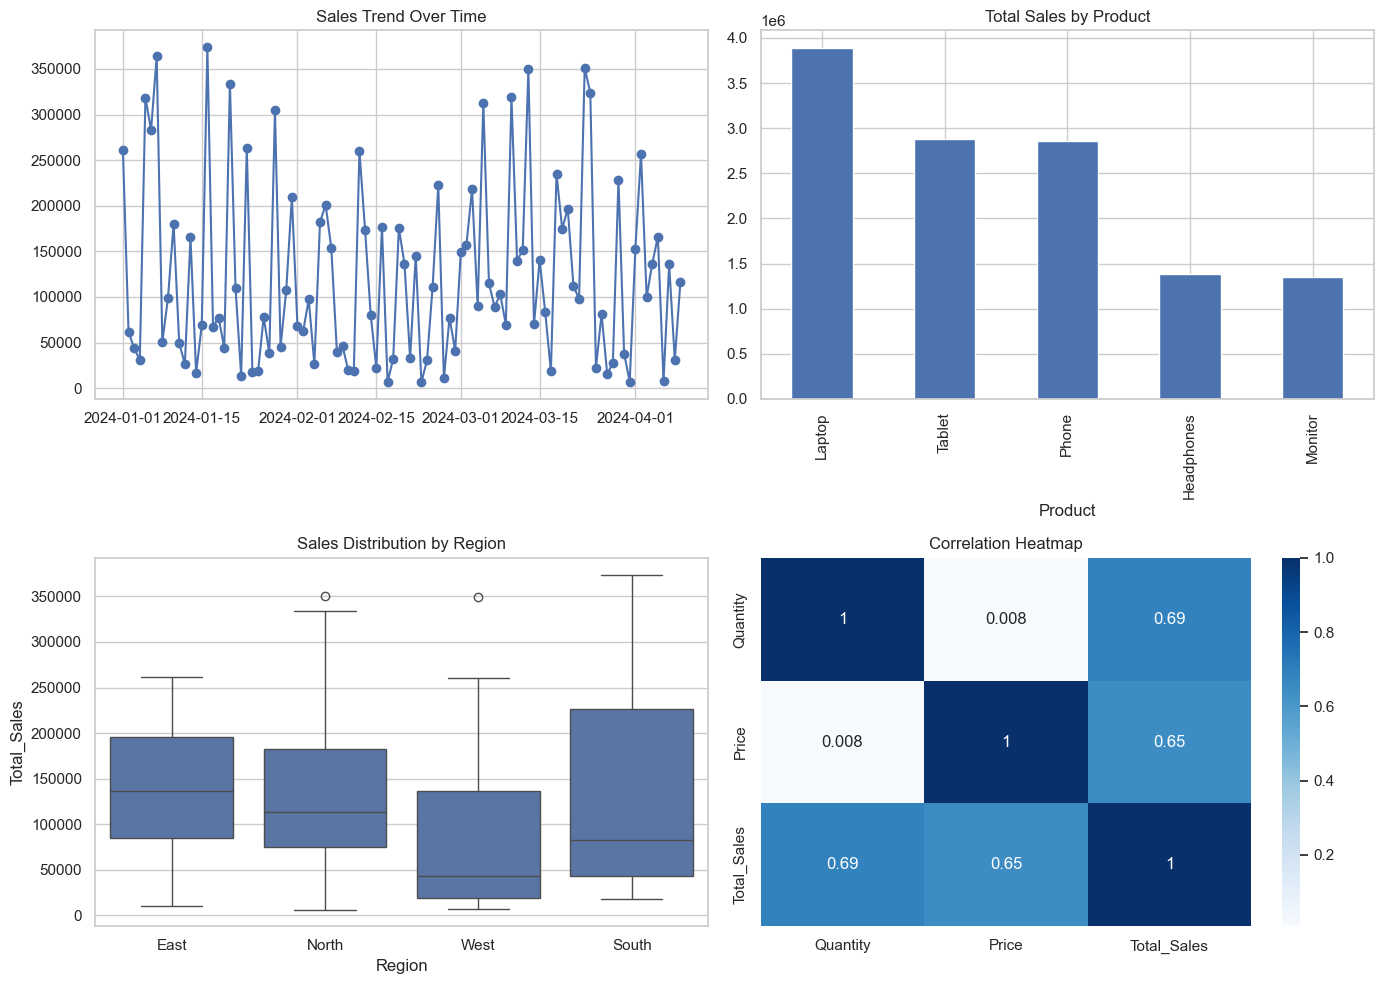

In [13]:
fig,axes = plt.subplots(2,2,figsize=(14,10))

# Trend
axes[0,0].plot(daily_sales["Date"],daily_sales["Total_Sales"],marker="o")
axes[0,0].set_title("Sales Trend Over Time")

# Product bar
product_sales.plot(kind="bar",ax=axes[0,1])
axes[0,1].set_title("Total Sales by Product")

# Region box
sns.boxplot(data=df,x="Region",y="Total_Sales",ax=axes[1,0])
axes[1,0].set_title("Sales Distribution by Region")

# Heatmap
sns.heatmap(corr,annot=True,cmap="Blues",ax=axes[1,1])
axes[1,1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()


## 12. Interactive Visualizations (Plotly)

These charts include hover effects to improve user understanding and dashboard interactivity.

In [15]:
fig_bar = px.bar(
    product_sales.reset_index(),
    x="Product",
    y="Total_Sales",
    title="Interactive : Total Sales by Product",
)
fig_bar.show()


In [16]:
fig_line = px.line(
    daily_sales,
    x="Date",
    y="Total_Sales",
    title="Interactive : Sales Trend Over Time",
)
fig_line.show()


## 13. Insights & Recommendations

### Key Insights
- Some products contribute more to revenue than others.
- Sales fluctuate over time,indicating variations in order sizes.
- Certain regions show higher sales spread and possible outliers.

### Recommendations
- Increase inventory and promotions for the top-selling products.
- Use trend analysis to plan discounts and seasonal campaigns.
- Focus marketing on high-performing regions and investigate low-sales regions.


## 14. Testing Evidence

Validation checks performed:
- Missing values check
- Duplicate row check
- Dataset shape verification


In [17]:
print("Missing values:",df.isnull().sum().sum())
print("Duplicates:",df.duplicated().sum())
print("Dataset shape:",df.shape)

Missing values: 0
Duplicates: 0
Dataset shape: (100, 9)
